# IMPORTANT

## Use the `anomaly_detect` kernel before running any cell.

- In terminal: `conda activate anomaly_detect`
- In notebook: select `Python (anomaly_detect)`

### CONDA ACTIVATE anom_detect 

In [5]:
# Load shared energy-line reference from models_phan.
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

ENERGY_LINES_REF_PATH = Path(r"C:\Users\phuynh\Projects\robotray-main\models_phan\energy_lines_ref.py")

spec = spec_from_file_location("energy_lines_ref", ENERGY_LINES_REF_PATH)
energy_lines_ref = module_from_spec(spec)
spec.loader.exec_module(energy_lines_ref)

# Use short notation (Ka/Kb/La/Lb) to match dataframe column names.
energy_lines = energy_lines_ref.get_energy_lines(notation="short", max_kev=40, sort_by_energy=True)
print(f"Number of energy lines: {len(energy_lines)}")
energy_lines[:10]

Number of energy lines: 155


[('Mg', 'Ka', 1.2536),
 ('Mg', 'Kb', 1.302),
 ('Al', 'Ka', 1.4867),
 ('Al', 'Kb', 1.55),
 ('Si', 'Ka', 1.74),
 ('Si', 'Kb', 1.836),
 ('P', 'Ka', 2.0137),
 ('Zr', 'La', 2.042),
 ('P', 'Kb', 2.139),
 ('Nb', 'La', 2.166)]

In [6]:
import pandas as pd
import numpy as np

# Example format expected:
# energy_lines = [
#     ("Mg", "K_alpha", 1.253),
#     ("Al", "K_alpha", 1.486),
#     ...
# ]

def import_df_snr_elem_mininghigh():
    csv_path = r"C:\Users\phuynh\Projects\robotray-main\models_phan\df_snr_elem.csv"
    df = pd.read_csv(csv_path)
    df_snr_elem_mininghigh = df[df["voltage"] == "mininghighvoltage"].copy()
    print(df_snr_elem_mininghigh.head())
    return df_snr_elem_mininghigh


def get_sorted_spec_cols(df_snr_elem_mininghigh, energy_lines):
    # Find the index where the spectra columns start.
    # Support both canonical (K_alpha) and short (Ka) column naming.
    spec_start_col = "Mg_Ka" if "Mg_Ka" in df_snr_elem_mininghigh.columns else "Mg_K_alpha"
    spec_start_idx = df_snr_elem_mininghigh.columns.get_loc(spec_start_col)
    spec_cols = df_snr_elem_mininghigh.columns[spec_start_idx:]

    # Build mapping from column name to energy
    energy_map = {f"{el}_{lt}": energy for el, lt, energy in energy_lines}

    # Sort only spectrum columns by mapped energy
    # Columns not found in energy_map go to the end
    sorted_spec_cols = sorted(spec_cols, key=lambda col: energy_map.get(col, float("inf")))

    return sorted_spec_cols, energy_map


if __name__ == "__main__":
    df_snr_elem_mininghigh = import_df_snr_elem_mininghigh()
    sorted_spec_cols, energy_map = get_sorted_spec_cols(df_snr_elem_mininghigh, energy_lines)

    print("First 10 sorted spectrum columns:")
    print(sorted_spec_cols[:10])

             voltage                                 test  target     Mg_Ka  \
0  mininghighvoltage  017762_2026_04_01_rutile_150_017762  rutile  0.109814   
1  mininghighvoltage  017762_2026_04_01_rutile_150_017763  rutile -0.529932   
2  mininghighvoltage  017762_2026_04_01_rutile_150_017764  rutile  0.487125   
3  mininghighvoltage  017762_2026_04_01_rutile_150_017765  rutile -0.058284   
4  mininghighvoltage  017762_2026_04_01_rutile_150_017766  rutile -1.024119   

      Mg_Kb     Al_Ka     Al_Kb     Si_Ka     Si_Kb      P_Ka  ...     Ag_Kb  \
0  0.548990  0.554102  0.125048 -0.202296  0.000576  0.071184  ...  0.120354   
1 -0.008598 -0.303985  0.061412 -0.337515  0.781507  0.003002  ...  1.075741   
2 -0.063574 -0.674423  0.588723 -0.607991  0.000020 -0.400131  ...  0.284871   
3  0.441546 -0.610237 -0.773682  0.178919 -0.534381 -0.059722  ... -0.217671   
4  0.866725  0.558372  0.422915 -0.674356  0.789002 -1.138609  ...  0.745373   

      Sn_Ka     Cd_Kb     Sb_Ka     In_Kb   

In [7]:
# for each unique target, how many rows are there?
print(df_snr_elem_mininghigh['target'].value_counts())

target
monazite-bra    750
quartz          750
rutile          749
nephe           749
tray            749
garnet          749
feldspar        748
zircon          743
Name: count, dtype: int64


### ANOMALY TEST 1:  CORRELATION WITH MEDIAN (CONCLUSION: FAIL, because signal too noisy)

In [8]:
# # Create a "correlation" column on the left of df_snr_elem_mininghigh.
# # For each unique target, calculate the median spectrum, and then for each row, calculate the correlation with the median of that unique target, and put that number in the "correlation" column.

# # Calculate median spectrum for each target
# target_medians = df_snr_elem_mininghigh.groupby('target')[spec_cols].median()

# def row_corr(row):
#     target = row['target']
#     spectrum = row[spec_cols].values.astype(float)
#     median_spectrum = target_medians.loc[target].values.astype(float)
#     # Use np.corrcoef for Pearson correlation
#     return np.corrcoef(spectrum, median_spectrum)[0, 1]

# # Remove 'correlation' column if it already exists
# if 'correlation' in df_snr_elem_mininghigh.columns:
#     df_snr_elem_mininghigh = df_snr_elem_mininghigh.drop(columns=['correlation'])
# # Calculate correlation for each row and insert as first column
# df_snr_elem_mininghigh.insert(0, 'correlation', df_snr_elem_mininghigh.apply(row_corr, axis=1))
# df_snr_elem_mininghigh.head()

In [9]:
# # Check for rows with constant values or near-zero variance in the spectrum columns
# X = df_snr_elem_mininghigh[spec_cols].values.astype(float)

# # Compute stats
# stds = X.std(axis=1)
# means = X.mean(axis=1)

# # Define threshold (relative)
# eps = 1e-6
# nzv_rows = stds < (eps * np.maximum(np.abs(means), 1e-12))

# # Constant rows are a subset of nzv
# const_rows = stds == 0

# print(f"Rows with constant values: {const_rows.sum()} / {len(X)}")
# print(f"Rows with near-zero variance: {nzv_rows.sum()} / {len(X)}")

# # Indices
# if const_rows.any():
#     print("Indices of constant rows:", df_snr_elem_mininghigh.index[const_rows].tolist())

# if nzv_rows.any():
#     print("Indices of near-zero variance rows:", df_snr_elem_mininghigh.index[nzv_rows].tolist())

In [10]:
# df_snr_elem_mininghigh['correlation'].describe()

In [11]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_target_spectra(df, target_name, spec_cols, energy_map=None):
#     # Filter target
#     df_t = df[df["target"] == target_name]

#     if df_t.empty:
#         print(f"No data for target: {target_name}")
#         return

#     # Extract spectra matrix
#     X = df_t[spec_cols].values.astype(float)

#     # Compute median
#     median = np.median(X, axis=0)

#     # X-axis: use energy if available, otherwise index
#     if energy_map is not None:
#         x = [energy_map.get(col, np.nan) for col in spec_cols]
#     else:
#         x = np.arange(len(spec_cols))

#     plt.figure(figsize=(10, 5))

#     # Plot all spectra in gray
#     for i in range(X.shape[0]):
#         plt.plot(x, X[i], color="gray", alpha=0.3)

#     # Plot median in black
#     plt.plot(x, median, color="black", linewidth=2, label="median")

#     plt.title(f"Spectra for target = {target_name}")
#     plt.xlabel("Energy (keV)" if energy_map else "Feature index")
#     plt.ylabel("Value")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# # Usage
# plot_target_spectra(
#     df_snr_elem_mininghigh,
#     target_name="nephe",
#     spec_cols=sorted_spec_cols,
#     energy_map=energy_map
# )

In [12]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_target_spectra_sample(df, target_name, spec_cols, energy_map=None, n_samples=20, random_state=42):
#     # Filter target
#     df_t = df[df["target"] == target_name]

#     if df_t.empty:
#         print(f"No data for target: {target_name}")
#         return

#     # Sample rows
#     df_sample = df_t.sample(n=min(n_samples, len(df_t)), random_state=random_state)

#     # Extract spectra
#     X = df_sample[spec_cols].values.astype(float)

#     # Compute median from ALL rows (not just sample)
#     median = np.median(df_t[spec_cols].values.astype(float), axis=0)

#     # X-axis
#     if energy_map is not None:
#         x = [energy_map.get(col, np.nan) for col in spec_cols]
#     else:
#         x = np.arange(len(spec_cols))

#     plt.figure(figsize=(10, 5))

#     # Plot sampled spectra in gray
#     for i in range(X.shape[0]):
#         plt.plot(x, X[i], color="gray", alpha=0.4)

#     # Plot median in black
#     plt.plot(x, median, color="black", linewidth=2, label="median")

#     plt.title(f"{n_samples} random spectra for target = {target_name}")
#     plt.xlabel("Energy (keV)" if energy_map else "Feature index")
#     plt.ylabel("Value")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# # Usage
# plot_target_spectra_sample(
#     df_snr_elem_mininghigh,
#     target_name="nephe",
#     spec_cols=sorted_spec_cols,
#     energy_map=energy_map,
#     n_samples=20
# )

In [13]:
# # Sort the spectrum columns by their energy level using energy_lines mapping
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))
# for target in target_medians.index:
#     plt.plot(sorted_spec_cols, target_medians.loc[target, sorted_spec_cols], label=target)
# plt.xlabel('Element/Energy (sorted by energy_lines)')
# plt.ylabel('Median Normalized Intensity')
# plt.title('Median Spectra for Each Target (Sorted by Energy)')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [14]:
# import matplotlib.pyplot as plt

# i = 1
# x = df_snr_elem_mininghigh.iloc[i][spec_cols].values
# m = target_medians.loc[df_snr_elem_mininghigh.iloc[i]['target']].values

# plt.plot(x, label='sample')
# plt.plot(m, label='median')
# plt.legend()

In [15]:
# df_snr_elem_mininghigh.groupby('target')['correlation'].describe()

In [16]:
# (X == 0).mean()

### ANOMALY TEST 2:  RMS 

In [17]:
import numpy as np
import pandas as pd

def add_rms_maha(df, spec_cols):
    df = df.copy()

    # Remove existing columns if present
    for col in ["rms", "maha"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    rms_series = []
    maha_series = []

    for target, group in df.groupby("target"):
        X = group[spec_cols].values.astype(float)

        # --- RMS (distance to median) ---
        median = np.median(X, axis=0)
        residuals = X - median
        rms = np.sqrt(np.mean(residuals**2, axis=1))

        # --- Mahalanobis ---
        mean = np.mean(X, axis=0)
        X_centered = X - mean

        cov = np.cov(X_centered, rowvar=False)

        # Regularization (critical)
        eps = 1e-6
        cov += np.eye(cov.shape[0]) * eps

        try:
            cov_inv = np.linalg.inv(cov)
        except np.linalg.LinAlgError:
            cov_inv = np.linalg.pinv(cov)

        maha = np.sqrt(np.sum((X_centered @ cov_inv) * X_centered, axis=1))

        rms_series.append(pd.Series(rms, index=group.index))
        maha_series.append(pd.Series(maha, index=group.index))

    rms_all = pd.concat(rms_series).sort_index()
    maha_all = pd.concat(maha_series).sort_index()

    # Insert at LEFT (position 0 and 1)
    df.insert(0, "rms", rms_all)
    df.insert(1, "maha", maha_all)

    return df


def describe_by_target(df):
    summary = df.groupby("target")[["rms", "maha"]].describe()
    return summary


# --- Usage ---
df_snr_elem_mininghigh = add_rms_maha(df_snr_elem_mininghigh, sorted_spec_cols)

summary = describe_by_target(df_snr_elem_mininghigh)

print(summary)

                rms                                                    \
              count      mean       std       min       25%       50%   
target                                                                  
feldspar      748.0  0.472396  0.034597  0.369081  0.449925  0.469945   
garnet        749.0  0.489198  0.047459  0.390494  0.461618  0.483149   
monazite-bra  750.0  0.470145  0.030494  0.380067  0.449061  0.470090   
nephe         749.0  0.472100  0.033269  0.390093  0.448676  0.470753   
quartz        750.0  0.469667  0.029820  0.383589  0.448443  0.468626   
rutile        749.0  0.485238  0.040451  0.380235  0.459271  0.481973   
tray          749.0  0.466789  0.029180  0.369963  0.448381  0.465059   
zircon        743.0  0.532118  0.128986  0.398457  0.472373  0.505066   

                                   maha                                  \
                   75%       max  count       mean       std        min   
target                                        

In [18]:
import numpy as np
import pandas as pd

def flag_anomalies_rms_maha(df):
    df = df.copy()

    # Remove old columns if they already exist
    for col in ["rms_thr", "maha_thr", "rms_anom", "maha_anom", "anom"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    def robust_threshold(x, k=3.0):
        x = np.asarray(x, dtype=float)
        med = np.median(x)
        mad = np.median(np.abs(x - med))

        # Consistent estimate of std under normality
        robust_sigma = 1.4826 * mad

        # Fallback if MAD is zero
        if robust_sigma < 1e-12:
            robust_sigma = np.std(x, ddof=0)

        return med + k * robust_sigma

    # Per-target thresholds
    df["rms_thr"] = df.groupby("target")["rms"].transform(lambda x: robust_threshold(x, k=3.0))
    df["maha_thr"] = df.groupby("target")["maha"].transform(lambda x: robust_threshold(x, k=3.0))

    # Flags
    df["rms_anom"] = df["rms"] > df["rms_thr"]
    df["maha_anom"] = df["maha"] > df["maha_thr"]
    df["anom"] = df["rms_anom"] | df["maha_anom"]

    return df


def get_anomalies(df):
    cols_first = [c for c in ["target", "rms", "rms_thr", "rms_anom", "maha", "maha_thr", "maha_anom", "anom"] if c in df.columns]
    other_cols = [c for c in df.columns if c not in cols_first]
    return df.loc[df["anom"], cols_first + other_cols].sort_values(
        ["target", "rms", "maha"], ascending=[True, False, False]
    )


# Run
df_snr_elem_mininghigh = flag_anomalies_rms_maha(df_snr_elem_mininghigh)
anom_df = get_anomalies(df_snr_elem_mininghigh)

print("Number of anomalies:", len(anom_df))
print("\nAnomalies per target:")
print(df_snr_elem_mininghigh.groupby("target")["anom"].sum())

print("\nTop anomalous rows:")
print(anom_df[["target", "rms", "rms_thr", "maha", "maha_thr", "rms_anom", "maha_anom"]].head(20))

Number of anomalies: 88

Anomalies per target:
target
feldspar         6
garnet          17
monazite-bra     0
nephe            1
quartz           2
rutile          15
tray             5
zircon          42
Name: anom, dtype: int64

Top anomalous rows:
        target       rms   rms_thr       maha   maha_thr  rms_anom  maha_anom
2154  feldspar  0.703304  0.567215  14.793998  13.842550      True       True
1797  feldspar  0.653081  0.567215  13.520911  13.842550      True      False
1690  feldspar  0.646051  0.567215  14.763959  13.842550      True       True
2122  feldspar  0.588815  0.567215  12.689105  13.842550      True      False
2104  feldspar  0.582732  0.567215  13.132186  13.842550      True      False
2132  feldspar  0.569283  0.567215  12.542129  13.842550      True      False
4536    garnet  0.810114  0.592535  12.695635  13.889954      True      False
5099    garnet  0.804445  0.592535  12.742287  13.889954      True      False
5206    garnet  0.781652  0.592535  12.399969 

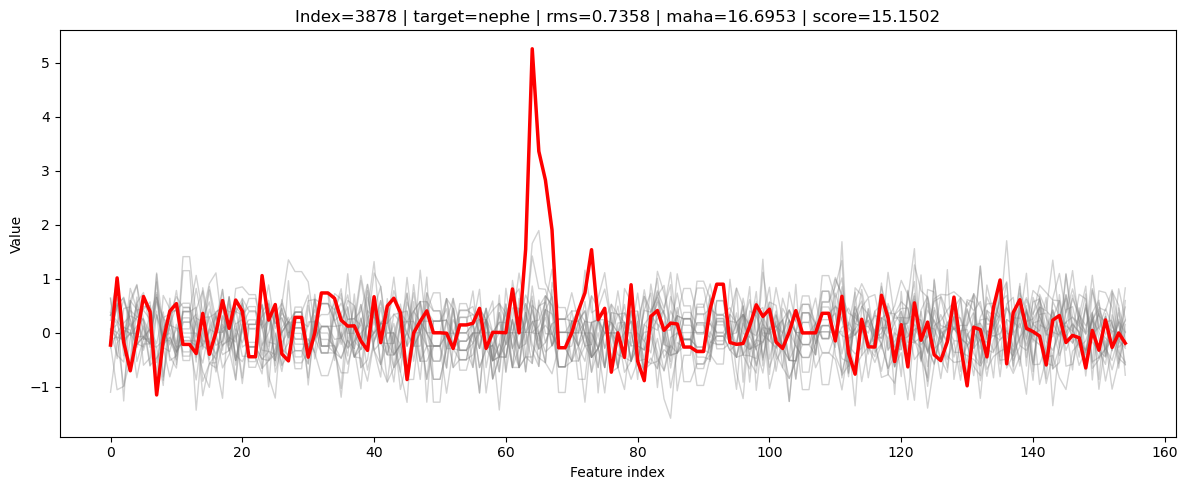

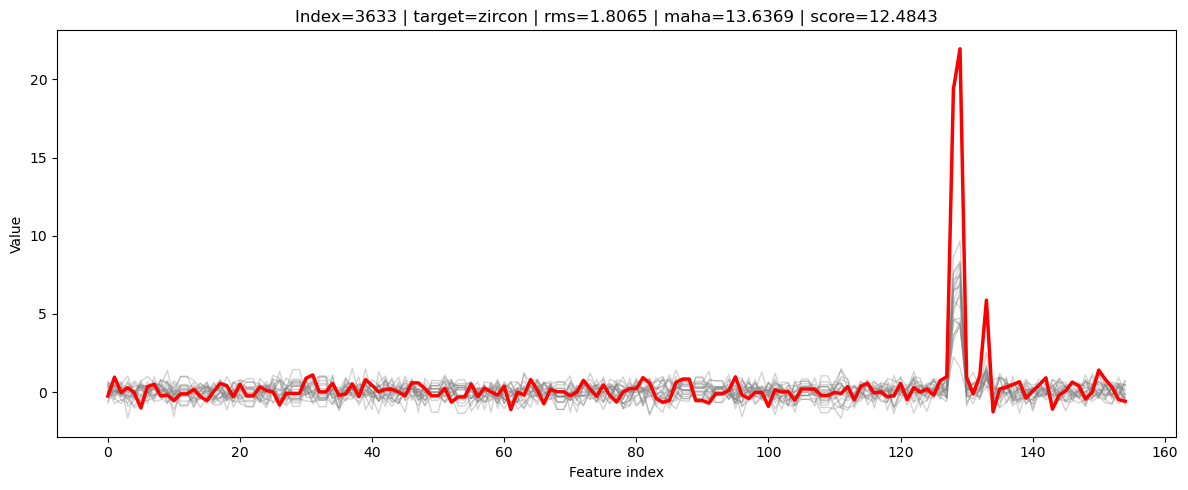

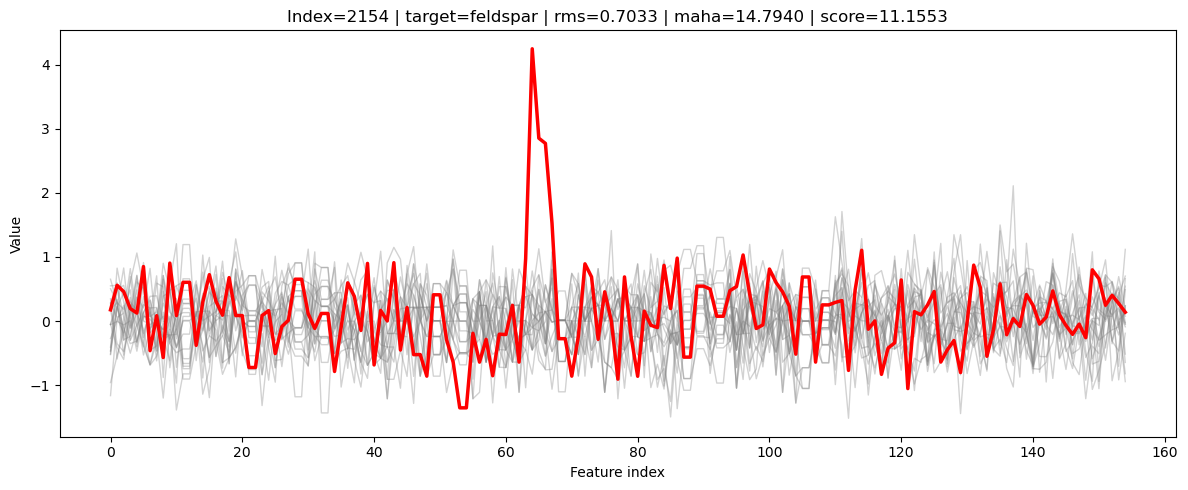

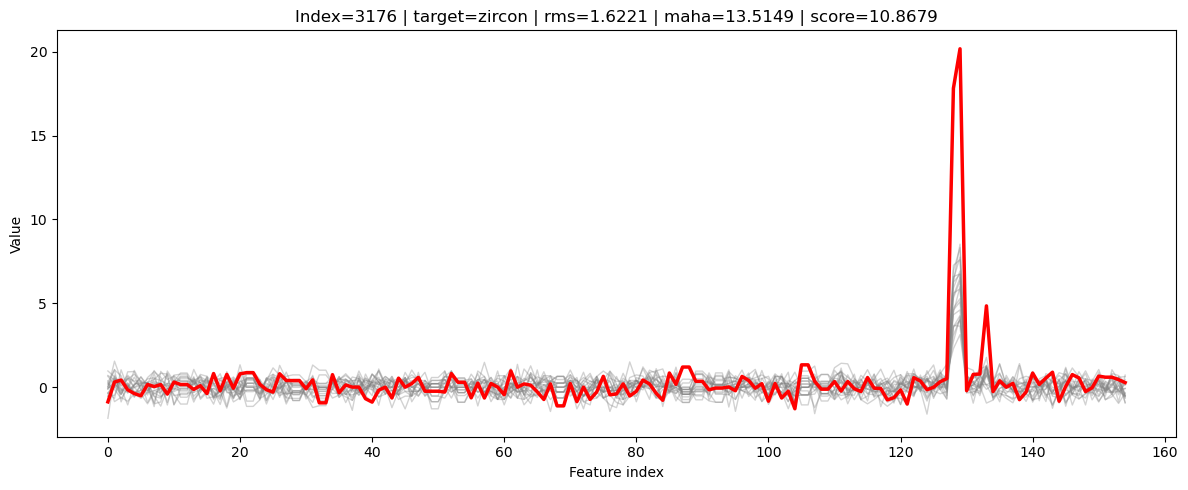

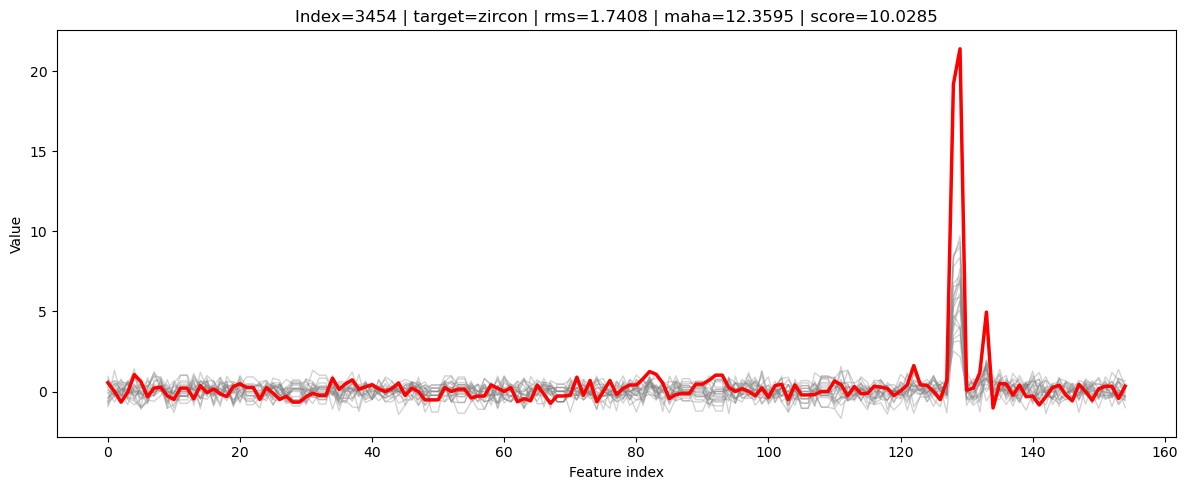

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_top5_anomalies_with_context(
    df,
    spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,
    energy_map=None
):
    df = df.copy()

    # Make a ranking score if it does not already exist
    if "anom_score" not in df.columns:
        df["rms_z"] = df.groupby("target")["rms"].transform(
            lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1)
        )
        df["maha_z"] = df.groupby("target")["maha"].transform(
            lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1)
        )
        df["anom_score"] = df["rms_z"] + df["maha_z"]

    # Keep only anomalous rows if available, otherwise just use highest scores
    if "anom" in df.columns:
        top_df = df[df["anom"]].sort_values("anom_score", ascending=False).head(top_n)
    else:
        top_df = df.sort_values("anom_score", ascending=False).head(top_n)

    if top_df.empty:
        print("No anomalous rows found.")
        return

    # X axis
    if use_energy and energy_map is not None:
        x = np.array([energy_map.get(col, np.nan) for col in spec_cols], dtype=float)
        xlabel = "Energy (keV)"
    else:
        x = np.arange(len(spec_cols))
        xlabel = "Feature index"

    rng = np.random.default_rng(random_state)

    for idx, row in top_df.iterrows():
        target = row["target"]

        # All rows from same target
        same_target = df[df["target"] == target]

        # Exclude the anomaly row itself from gray context if possible
        context_df = same_target.drop(index=idx, errors="ignore")

        if len(context_df) > 0:
            n_take = min(n_random, len(context_df))
            sampled_idx = rng.choice(context_df.index.to_numpy(), size=n_take, replace=False)
            context_sample = context_df.loc[sampled_idx]
        else:
            context_sample = context_df

        plt.figure(figsize=(12, 5))

        # Gray context spectra
        for _, ctx_row in context_sample.iterrows():
            y_ctx = ctx_row[spec_cols].values.astype(float)
            plt.plot(x, y_ctx, color="gray", alpha=0.35, linewidth=1)

        # Red anomaly spectrum
        y_anom = row[spec_cols].values.astype(float)
        plt.plot(x, y_anom, color="red", linewidth=2.5)

        title_parts = [
            f"Index={idx}",
            f"target={target}",
            f"rms={row['rms']:.4f}",
            f"maha={row['maha']:.4f}"
        ]
        if "anom_score" in row.index:
            title_parts.append(f"score={row['anom_score']:.4f}")

        plt.title(" | ".join(title_parts))
        plt.xlabel(xlabel)
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()


# Usage
plot_top5_anomalies_with_context(
    df=df_snr_elem_mininghigh,
    spec_cols=sorted_spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,      # set True only if you really want keV on x-axis
    energy_map=energy_map  # only used if use_energy=True
)

### ANOMALY TEST 3:  PCA + Distance

In [20]:
import numpy as np
import pandas as pd

def add_pca_distance_numpy(df, spec_cols, n_components=5):
    df = df.copy()

    # Remove existing column if present
    if "pca_dist" in df.columns:
        df = df.drop(columns=["pca_dist"])

    pca_dist_series = []

    for target, group in df.groupby("target"):
        X = group[spec_cols].values.astype(float)

        n_rows, n_features = X.shape
        if n_rows < 2 or n_features < 1:
            dist = np.zeros(n_rows, dtype=float)
            pca_dist_series.append(pd.Series(dist, index=group.index))
            continue

        # Standardize within target
        mean = X.mean(axis=0)
        std = X.std(axis=0, ddof=0)

        # Avoid divide-by-zero for constant features
        std_safe = std.copy()
        std_safe[std_safe == 0] = 1.0

        X_scaled = (X - mean) / std_safe

        # Safe number of components
        n_comp = min(n_components, n_rows - 1, n_features)
        if n_comp < 1:
            dist = np.zeros(n_rows, dtype=float)
            pca_dist_series.append(pd.Series(dist, index=group.index))
            continue

        # PCA via SVD
        # X_scaled = U S Vt
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)

        # Scores in PCA space = X_scaled @ V
        # Equivalent to U * S
        X_pca = U[:, :n_comp] * S[:n_comp]

        # Distance from center in PCA space
        center = X_pca.mean(axis=0)
        dist = np.linalg.norm(X_pca - center, axis=1)

        pca_dist_series.append(pd.Series(dist, index=group.index))

    pca_dist_all = pd.concat(pca_dist_series).sort_index()

    # Insert on the left
    df.insert(0, "pca_dist", pca_dist_all)

    return df


def describe_pca_distance_by_target(df):
    return df.groupby("target")["pca_dist"].describe()


# Usage
df_snr_elem_mininghigh = add_pca_distance_numpy(
    df_snr_elem_mininghigh,
    spec_cols=sorted_spec_cols,
    n_components=5
)

pca_summary = describe_pca_distance_by_target(df_snr_elem_mininghigh)
print(pca_summary)

              count      mean       std       min       25%       50%  \
target                                                                  
feldspar      748.0  3.836617  1.246881  0.692159  2.981039  3.781436   
garnet        749.0  3.975755  1.335725  0.768161  3.032146  3.919837   
monazite-bra  750.0  3.800155  1.244617  0.527642  2.986880  3.756888   
nephe         749.0  3.819331  1.298243  0.782813  2.808296  3.763758   
quartz        750.0  3.763627  1.204377  0.950877  2.947865  3.651246   
rutile        749.0  3.838779  1.345336  0.739906  2.845290  3.719244   
tray          749.0  3.716703  1.187704  0.875970  2.902776  3.644595   
zircon        743.0  3.839735  1.375243  0.813756  2.929200  3.725555   

                   75%        max  
target                             
feldspar      4.654696   9.437749  
garnet        4.753121  10.068269  
monazite-bra  4.675732   7.496648  
nephe         4.675360   7.694035  
quartz        4.595116   7.644779  
rutile        4.6

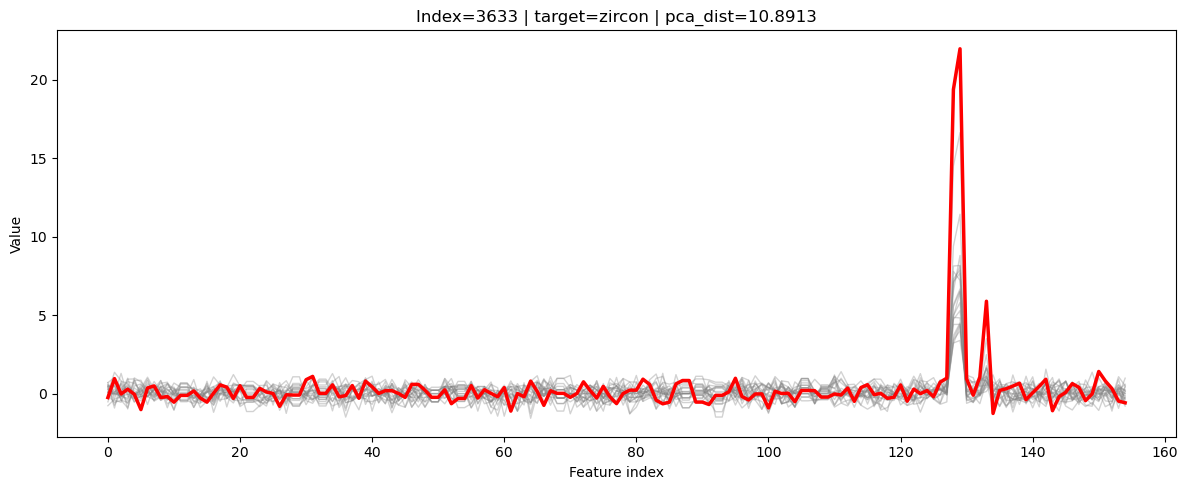

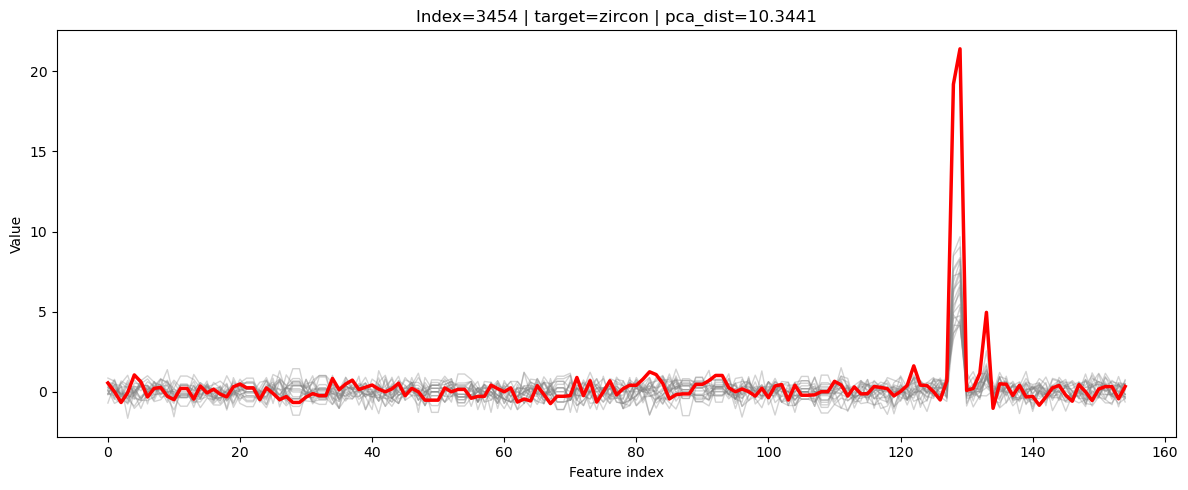

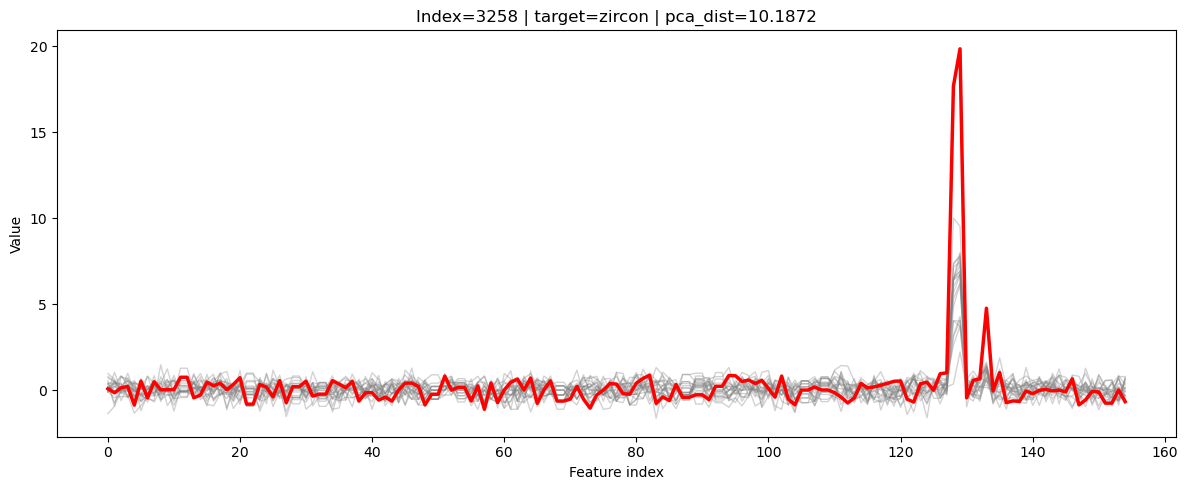

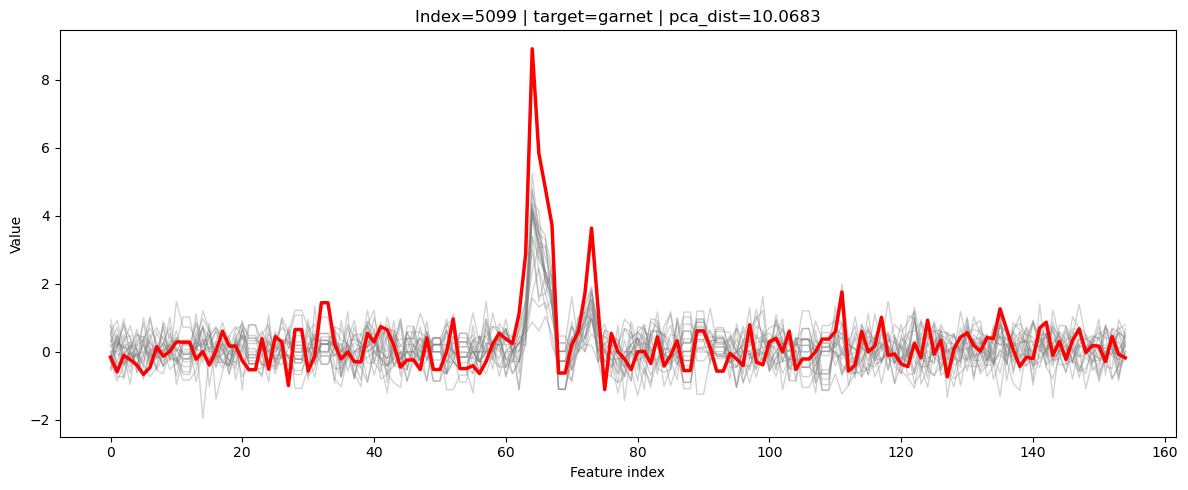

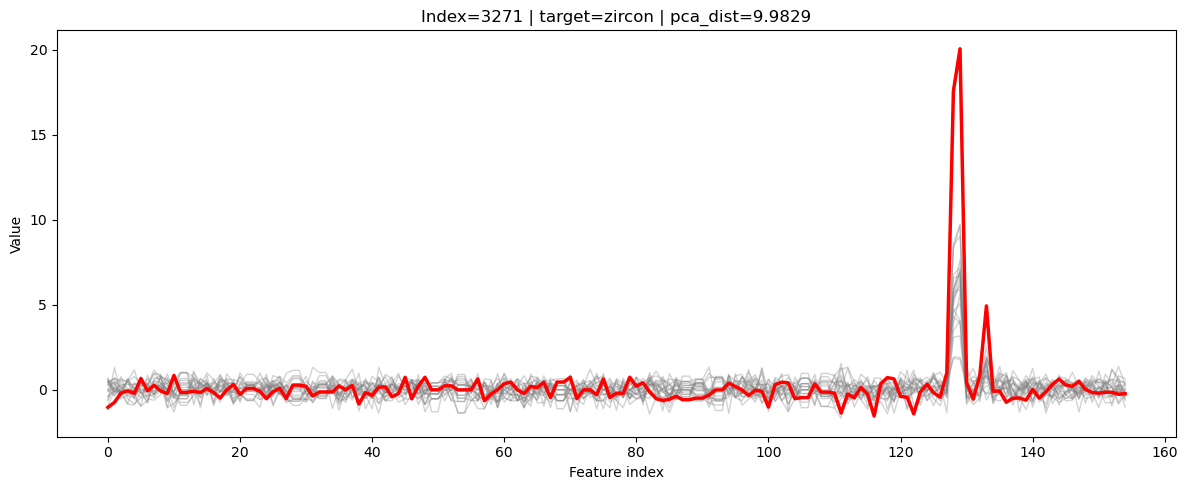

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_top5_pca_anomalies_with_context(
    df,
    spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,
    energy_map=None
):
    df = df.copy()

    if "pca_dist" not in df.columns:
        raise ValueError("Column 'pca_dist' not found. Run add_pca_distance first.")

    # Top rows by PCA distance
    top_df = df.sort_values("pca_dist", ascending=False).head(top_n)

    if top_df.empty:
        print("No rows found.")
        return

    # X axis
    if use_energy and energy_map is not None:
        x = np.array([energy_map.get(col, np.nan) for col in spec_cols], dtype=float)
        xlabel = "Energy (keV)"
    else:
        x = np.arange(len(spec_cols))
        xlabel = "Feature index"

    rng = np.random.default_rng(random_state)

    for idx, row in top_df.iterrows():
        target = row["target"]

        # All rows from same target
        same_target = df[df["target"] == target]

        # Exclude the selected row from gray context
        context_df = same_target.drop(index=idx, errors="ignore")

        if len(context_df) > 0:
            n_take = min(n_random, len(context_df))
            sampled_idx = rng.choice(context_df.index.to_numpy(), size=n_take, replace=False)
            context_sample = context_df.loc[sampled_idx]
        else:
            context_sample = context_df

        plt.figure(figsize=(12, 5))

        # Gray context spectra
        for _, ctx_row in context_sample.iterrows():
            y_ctx = ctx_row[spec_cols].values.astype(float)
            plt.plot(x, y_ctx, color="gray", alpha=0.35, linewidth=1)

        # Red selected spectrum
        y_sel = row[spec_cols].values.astype(float)
        plt.plot(x, y_sel, color="red", linewidth=2.5)

        plt.title(
            f"Index={idx} | target={target} | pca_dist={row['pca_dist']:.4f}"
        )
        plt.xlabel(xlabel)
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()


# Usage
plot_top5_pca_anomalies_with_context(
    df=df_snr_elem_mininghigh,
    spec_cols=sorted_spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,      # set True only if you want keV labels
    energy_map=energy_map
)

### ANOMALY TEST 4:  ISOLATION FOREST

              count      mean       std       min       25%       50%  \
target                                                                  
feldspar      748.0  0.062128  0.011490  0.025312  0.055132  0.062370   
garnet        749.0  0.060971  0.011941  0.023350  0.053572  0.061750   
monazite-bra  750.0  0.060708  0.011316  0.019656  0.053384  0.061226   
nephe         749.0  0.061307  0.011758  0.026709  0.054199  0.061016   
quartz        750.0  0.059356  0.011079  0.015817  0.052309  0.059689   
rutile        749.0  0.058890  0.011466  0.020872  0.051730  0.058860   
tray          749.0  0.061219  0.010902  0.028056  0.054066  0.061628   
zircon        743.0  0.063175  0.011366  0.028350  0.055279  0.063283   

                   75%       max  
target                            
feldspar      0.069997  0.093879  
garnet        0.068993  0.094113  
monazite-bra  0.068677  0.092525  
nephe         0.069688  0.090619  
quartz        0.067352  0.090617  
rutile        0.066560  

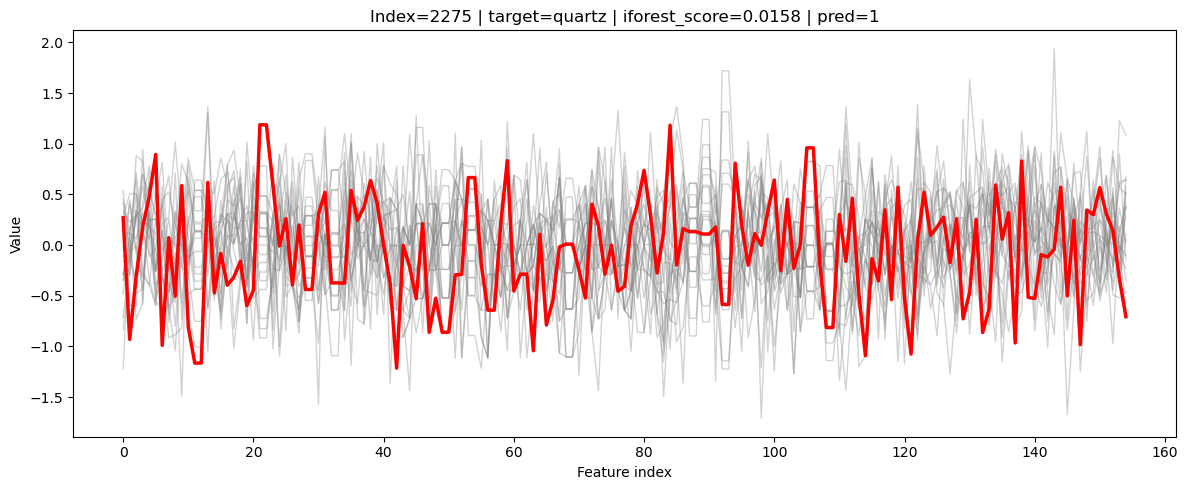

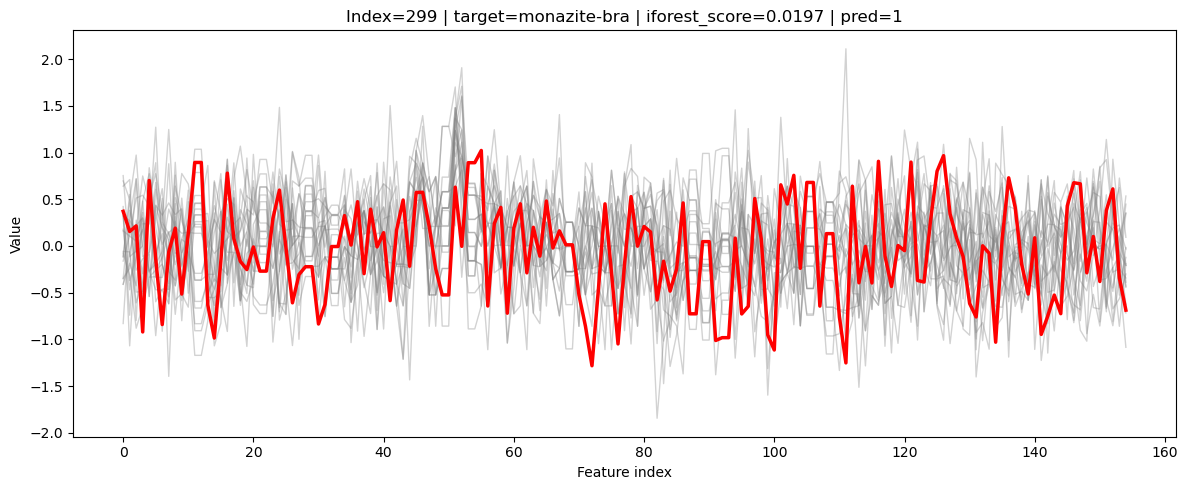

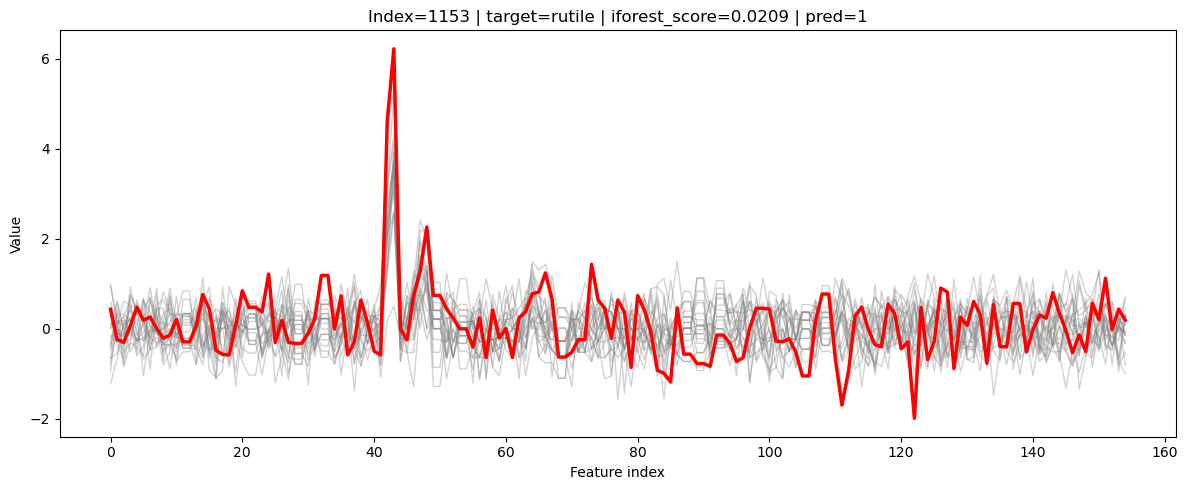

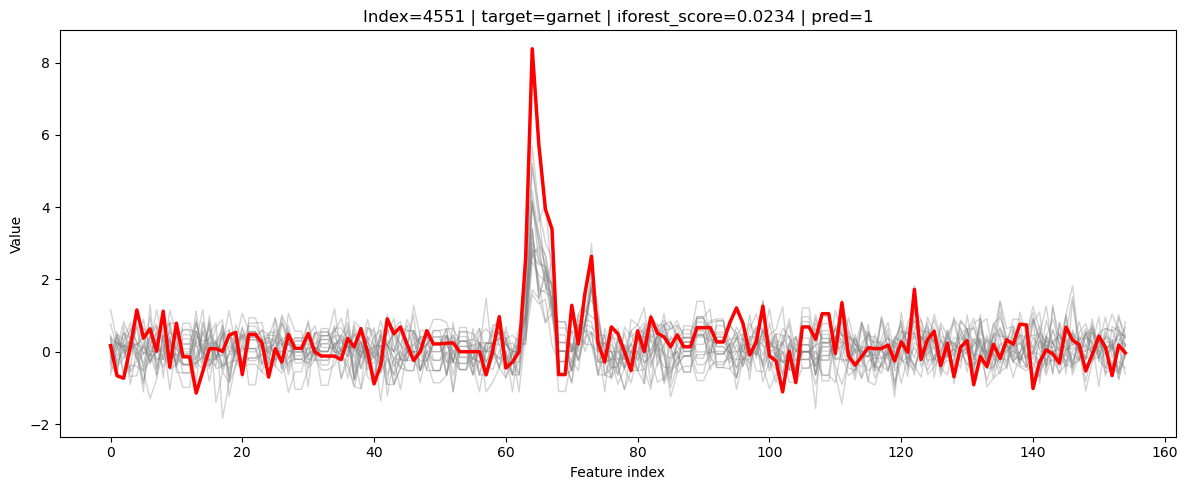

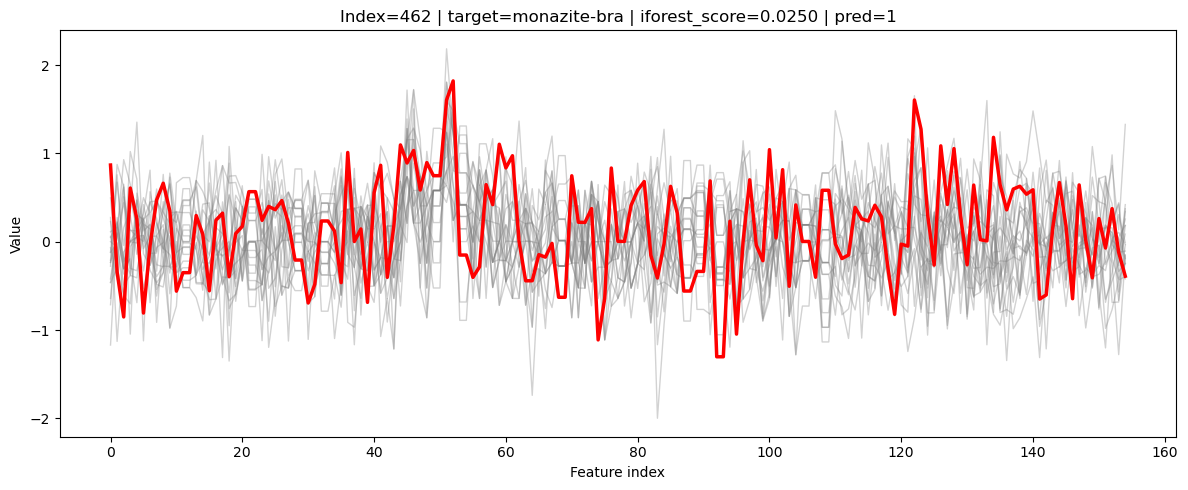

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_isoforest_score(df, spec_cols, random_state=42, n_estimators=300):
    # sklearn import kept inside because your env may fail here
    from sklearn.ensemble import IsolationForest
    from sklearn.preprocessing import StandardScaler

    df = df.copy()

    # Remove existing columns if present
    for col in ["iforest_score", "iforest_pred", "iforest_anom"]:
        if col in df.columns:
            df = df.drop(columns=[col])

    score_series = []
    pred_series = []
    anom_series = []

    for target, group in df.groupby("target"):
        X = group[spec_cols].values.astype(float)

        # Standardize within target
        mean = X.mean(axis=0)
        std = X.std(axis=0, ddof=0)
        std[std == 0] = 1.0
        X_scaled = (X - mean) / std

        clf = IsolationForest(
            n_estimators=n_estimators,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1
        )
        clf.fit(X_scaled)

        # Higher = more normal, lower = more anomalous
        score = clf.decision_function(X_scaled)

        # predict: 1=inlier, -1=outlier
        pred = clf.predict(X_scaled)
        anom = pred == -1

        score_series.append(pd.Series(score, index=group.index))
        pred_series.append(pd.Series(pred, index=group.index))
        anom_series.append(pd.Series(anom, index=group.index))

    score_all = pd.concat(score_series).sort_index()
    pred_all = pd.concat(pred_series).sort_index()
    anom_all = pd.concat(anom_series).sort_index()

    # Insert on the left
    df.insert(0, "iforest_score", score_all)
    df.insert(1, "iforest_pred", pred_all)
    df.insert(2, "iforest_anom", anom_all)

    return df


def describe_iforest_by_target(df):
    return df.groupby("target")["iforest_score"].describe()


def plot_top5_iforest_anomalies_with_context(
    df,
    spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,
    energy_map=None
):
    if "iforest_score" not in df.columns:
        raise ValueError("Column 'iforest_score' not found. Run add_isoforest_score first.")

    # Most anomalous = lowest decision_function
    if "iforest_anom" in df.columns and df["iforest_anom"].any():
        top_df = df[df["iforest_anom"]].sort_values("iforest_score", ascending=True).head(top_n)
    else:
        # Fallback: just show the 5 lowest scores
        top_df = df.sort_values("iforest_score", ascending=True).head(top_n)

    if top_df.empty:
        print("No rows found.")
        return

    if use_energy and energy_map is not None:
        x = np.array([energy_map.get(col, np.nan) for col in spec_cols], dtype=float)
        xlabel = "Energy (keV)"
    else:
        x = np.arange(len(spec_cols))
        xlabel = "Feature index"

    rng = np.random.default_rng(random_state)

    for idx, row in top_df.iterrows():
        target = row["target"]
        same_target = df[df["target"] == target]
        context_df = same_target.drop(index=idx, errors="ignore")

        if len(context_df) > 0:
            n_take = min(n_random, len(context_df))
            sampled_idx = rng.choice(context_df.index.to_numpy(), size=n_take, replace=False)
            context_sample = context_df.loc[sampled_idx]
        else:
            context_sample = context_df

        plt.figure(figsize=(12, 5))

        for _, ctx_row in context_sample.iterrows():
            y_ctx = ctx_row[spec_cols].values.astype(float)
            plt.plot(x, y_ctx, color="gray", alpha=0.35, linewidth=1)

        y_sel = row[spec_cols].values.astype(float)
        plt.plot(x, y_sel, color="red", linewidth=2.5)

        plt.title(
            f"Index={idx} | target={target} | iforest_score={row['iforest_score']:.4f} | pred={int(row['iforest_pred'])}"
        )
        plt.xlabel(xlabel)
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()


# --- Run it ---
df_snr_elem_mininghigh = add_isoforest_score(
    df_snr_elem_mininghigh,
    spec_cols=sorted_spec_cols,
    random_state=42,
    n_estimators=300
)

print(describe_iforest_by_target(df_snr_elem_mininghigh))
print("\nAnomalies per target:")
print(df_snr_elem_mininghigh.groupby("target")["iforest_anom"].sum())

plot_top5_iforest_anomalies_with_context(
    df=df_snr_elem_mininghigh,
    spec_cols=sorted_spec_cols,
    top_n=5,
    n_random=20,
    random_state=42,
    use_energy=False,
    energy_map=energy_map
)

In [23]:
# Summary: how each anomaly test is performing on the current dataframe
import numpy as np
import pandas as pd

n_total = len(df_snr_elem_mininghigh)
rows = []

if "anom" in df_snr_elem_mininghigh.columns:
    n_flag = int(df_snr_elem_mininghigh["anom"].sum())
    rows.append({
        "test": "RMS + Mahalanobis (per-target robust threshold)",
        "flagged_rows": n_flag,
        "flagged_pct": 100 * n_flag / n_total,
        "notes": "Binary anomaly flag available (anom = rms_anom OR maha_anom)",
    })

if "pca_dist" in df_snr_elem_mininghigh.columns:
    p95 = float(df_snr_elem_mininghigh["pca_dist"].quantile(0.95))
    n_top5pct = int((df_snr_elem_mininghigh["pca_dist"] >= p95).sum())
    rows.append({
        "test": "PCA distance",
        "flagged_rows": n_top5pct,
        "flagged_pct": 100 * n_top5pct / n_total,
        "notes": "No built-in binary flag here; shown as top 5% highest pca_dist",
    })

if "iforest_anom" in df_snr_elem_mininghigh.columns:
    n_flag = int(df_snr_elem_mininghigh["iforest_anom"].sum())
    rows.append({
        "test": "Isolation Forest",
        "flagged_rows": n_flag,
        "flagged_pct": 100 * n_flag / n_total,
        "notes": "Binary anomaly flag available (iforest_anom)",
    })

summary_df = pd.DataFrame(rows)
if not summary_df.empty:
    summary_df["flagged_pct"] = summary_df["flagged_pct"].map(lambda x: f"{x:.2f}%")

print(f"Total rows analyzed: {n_total}")
display(summary_df)

# Optional: per-target anomaly counts for tests that have binary flags
per_target_cols = [c for c in ["anom", "iforest_anom"] if c in df_snr_elem_mininghigh.columns]
if per_target_cols:
    print("\nPer-target anomaly counts:")
    display(df_snr_elem_mininghigh.groupby("target")[per_target_cols].sum().sort_index())

Total rows analyzed: 5987


,test,flagged_rows,flagged_pct,notes
0,RMS + Mahalanobis (per-target robust threshold),88,1.47%,Binary anomaly flag available (anom = rms_anom...
1,PCA distance,300,5.01%,No built-in binary flag here; shown as top 5% ...
2,Isolation Forest,0,0.00%,Binary anomaly flag available (iforest_anom)



Per-target anomaly counts:


,anom,iforest_anom
target,,
feldspar,6,0
garnet,17,0
monazite-bra,0,0
nephe,1,0
quartz,2,0
rutile,15,0
tray,5,0
zircon,42,0
